# Analyze a shipped agent's training log

Every agent under `data/agents/` ships a `train.log` that records, every
few rollouts, the running win rate against each opponent in the pool. This
notebook parses that log and plots the learning curve for
`UECD-SingleMap-Best` (the final agent of the dissertation).

CPU-only, no Java needed (pure pandas / matplotlib). Re-uses the same
parser the dissertation figure scripts use, so the curves you get here
match what is in the PDF.

**Prereq**: run from the repo root (`jupyter lab` in the project dir).

## 1. Parse the train.log

In [1]:
import sys

from microrts_agent.paths import PROJECT_ROOT

# The thesis figure scripts ship a parser at this path; reuse it so the
# curves we produce here match the published figures byte-for-byte.
sys.path.insert(0, str(PROJECT_ROOT / "dissertation" / "figs" / "figs-python"))

from _data import parse_train_log, smooth  # noqa: E402

print("Repo root:", PROJECT_ROOT)
print("Parser   :", parse_train_log.__module__)

Repo root: /Users/mathisdelsart/Desktop/microrts-drl-uecd
Parser   : _data


In [2]:
# `parse_train_log` resolves the run name against data/agents/ first, then
# data/ablation/, then outputs/runs/. Returns a DataFrame with columns
# step, ret (return), len (episode length), and wr_<Bot> per opponent.
df = parse_train_log("UECD-SingleMap-Best")
print(f"Rows: {len(df)}, columns: {list(df.columns)}")
df.head()

Rows: 152, columns: ['step', 'ret', 'len', 'wr_RAIS', 'wr_Self', 'wr_Coac', 'wr_Maya', 'wr_ObiB', 'wr_TMA']


,step,ret,len,wr_RAIS,wr_Self,wr_Coac,wr_Maya,wr_ObiB,wr_TMA
0,240708264,80.2,785,0.00,0.12,0.74,0.80,0.44,0.54
1,241376784,72.0,742,0.02,0.54,0.80,0.74,0.42,0.50
2,242075448,267.6,1448,0.00,0.28,0.96,0.90,0.72,0.80
3,242803920,225.4,1074,0.12,0.56,1.00,1.00,0.92,0.98
4,243582096,149.4,754,0.06,0.40,0.98,1.00,0.88,1.00


## 2. Plot the learning curve per opponent

Each `wr_<Bot>` column is the rolling win rate against that opponent at
the point recorded in the log. We plot one line per opponent vs step
(in millions).

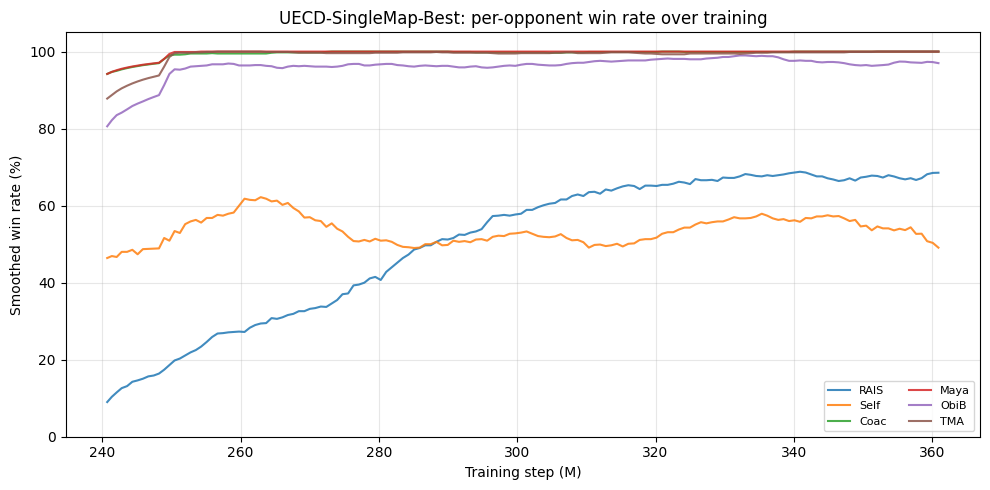

In [3]:
import matplotlib.pyplot as plt

wr_cols = [c for c in df.columns if c.startswith("wr_")]

fig, ax = plt.subplots(figsize=(10, 5))
for col in wr_cols:
    bot = col[len("wr_") :]
    ax.plot(df["step"] / 1e6, smooth(df[col].values, window=20) * 100, label=bot, alpha=0.85)
ax.set_xlabel("Training step (M)")
ax.set_ylabel("Smoothed win rate (%)")
ax.set_title("UECD-SingleMap-Best: per-opponent win rate over training")
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 3. Pool mean win rate (overall progress)

Average across all opponents at each step: one curve that summarises the
agent's overall competence.

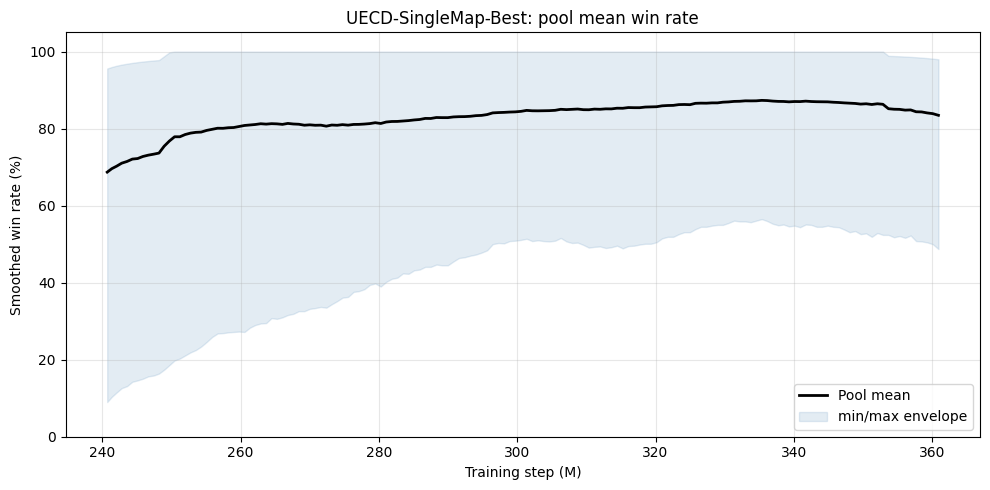

Final pool mean WR: 61.0%
Final step        : 361 M


In [4]:
pool_mean = df[wr_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df["step"] / 1e6,
    smooth(pool_mean.values, window=20) * 100,
    color="black",
    linewidth=2,
    label="Pool mean",
)
ax.fill_between(
    df["step"] / 1e6,
    smooth(df[wr_cols].min(axis=1).values, window=20) * 100,
    smooth(df[wr_cols].max(axis=1).values, window=20) * 100,
    alpha=0.15,
    color="steelblue",
    label="min/max envelope",
)
ax.set_xlabel("Training step (M)")
ax.set_ylabel("Smoothed win rate (%)")
ax.set_title("UECD-SingleMap-Best: pool mean win rate")
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final pool mean WR: {pool_mean.iloc[-1] * 100:.1f}%")
print(f"Final step        : {df['step'].iloc[-1] / 1e6:.0f} M")

## 4. Compare to another shipped agent

Same parser works on any agent under `data/agents/`. Quick side-by-side
of the GridNet baseline (300M steps) vs UECD-SingleMap-Best (350M steps,
the dissertation's headline).

In [ ]:
df_gridnet = parse_train_log("GridNet-SingleMap")
df_best = df  # already loaded above

wr_cols_gridnet = [c for c in df_gridnet.columns if c.startswith("wr_")]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df_gridnet["step"] / 1e6,
    smooth(df_gridnet[wr_cols_gridnet].mean(axis=1).values, window=20) * 100,
    label="GridNet-SingleMap (baseline)",
    linewidth=2,
    color="#888",
)
ax.plot(
    df_best["step"] / 1e6,
    smooth(df_best[wr_cols].mean(axis=1).values, window=20) * 100,
    label="UECD-SingleMap-Best (final)",
    linewidth=2,
    color="#1f77b4",
)
ax.set_xlabel("Training step (M)")
ax.set_ylabel("Pool mean win rate (%)")
ax.set_title("GridNet baseline vs UECD-SingleMap-Best")
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Next steps

- Replace `"UECD-SingleMap-Best"` above with any agent under
  `data/agents/` (try `UECD-MultiMap-Best`, `UECD-BC-PPO`, etc.).
- Replace with an ablation run name (e.g., `extended_obs_s1`,
  `hl_gauss_s1`) to inspect a feature ablation curve.
- See `dissertation/figs/figs-python/best_vs_stier_100M.py` for the
  full figure-grade plotting that uses this same parser.